# Experiment 4: Comparing model performance as learning rate changes

In this experiment, we'll evaluate how model accuracy depends on the learning rate. We'll again use three simple CV datasets, MNIST, Fashion-MNIST, and CIFAR-10.

Note that these experiments are done with a constant number of epochs, and without learning rate scheduling. If more epochs were used, smaller learning rates could achieve better results.

#### Imports and Setup

In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

In [2]:
import torch
import matplotlib.pyplot as plt

from utils.train import fit, val_stats, load_model
from utils.hparams import (MLPHyperParameters, 
                         CNNHyperParameters)

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


#### Learning rates

In [ ]:
lr_sweep = [10**(i) for i in range(-6, 2)]
print(lr_sweep)

optimizer_sweep = [torch.optim.SGD, torch.optim.Adam]

[1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10]


In [5]:
mlp_val_accuracies = [[[],[],[]], [[],[],[]]]
cnn_val_accuracies = [[[],[],[]], [[],[],[]]]

In [6]:
def get_hp(model_name, dataset, **kwargs):
    match model_name:
        case 'MLP':
            return MLPHyperParameters(dataset=dataset, 
                                      id=f'{dataset} {model_name}, {kwargs}', 
                                      **kwargs)
        case 'CNN':
            return CNNHyperParameters(dataset=dataset, 
                                      id=f'{dataset} {model_name}, {kwargs}', 
                                      **kwargs)
        case _:
            raise ValueError(f"Model name {model_name} is unspecified")

### MNIST Experiments

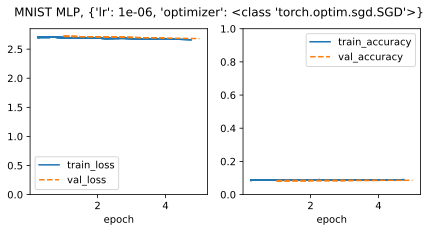

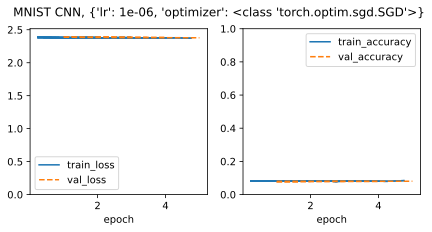

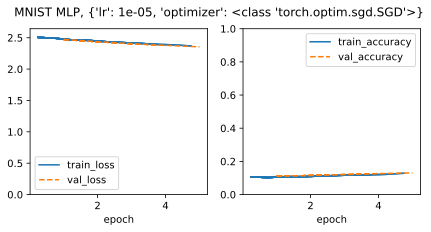

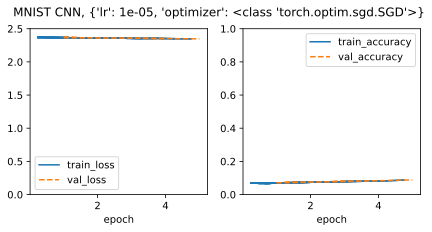

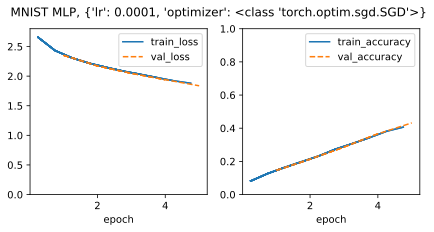

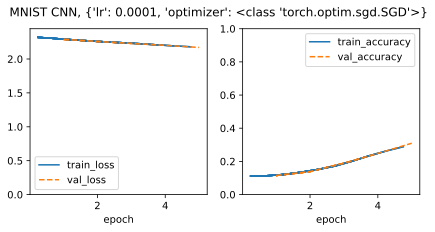

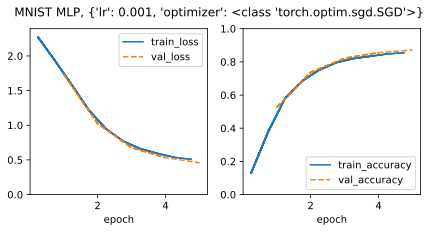

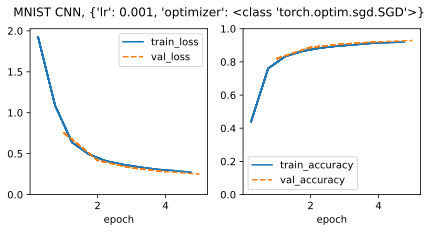

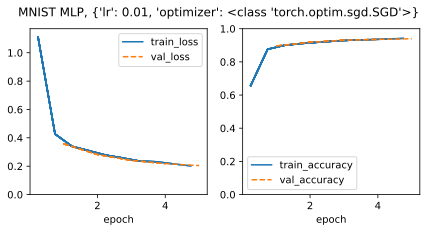

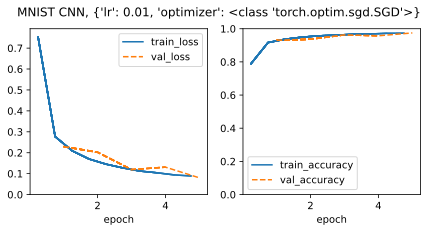

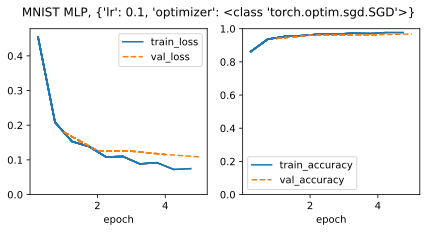

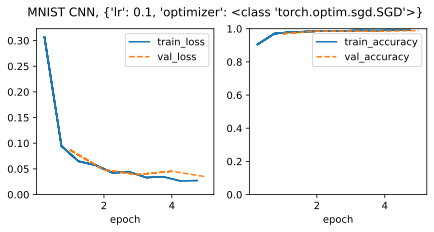

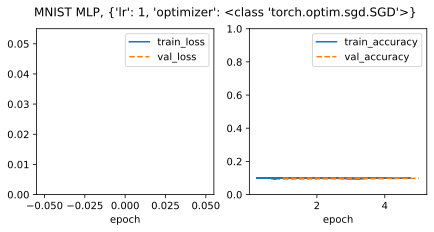

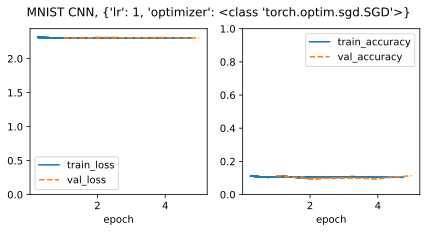

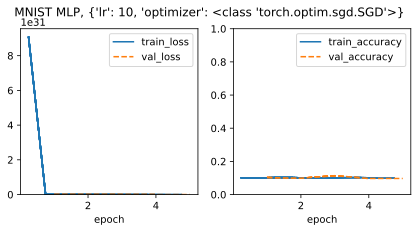

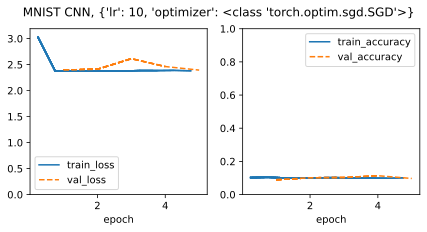

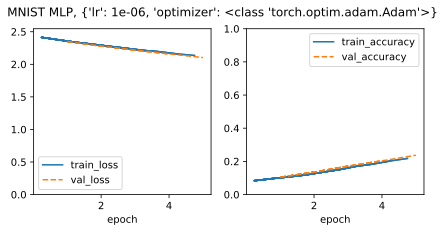

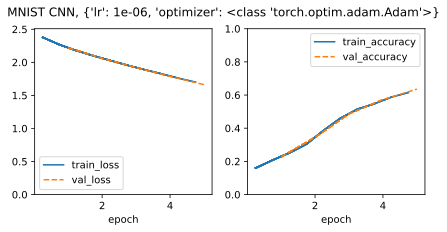

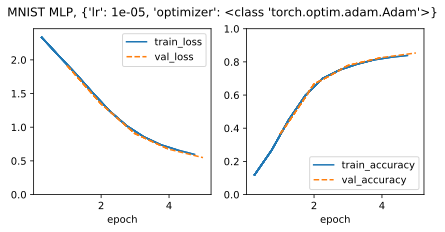

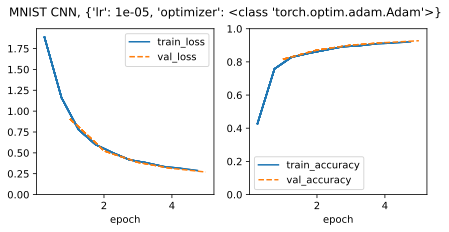

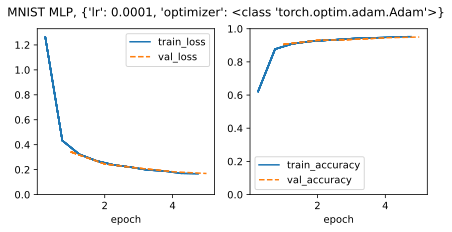

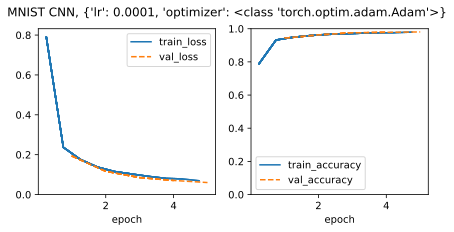

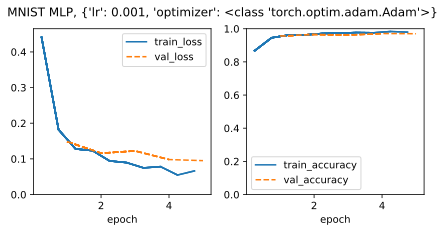

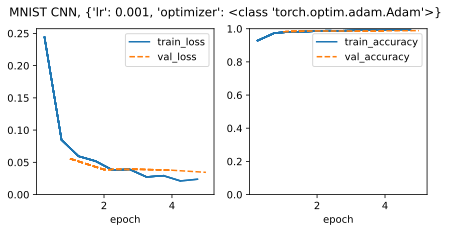

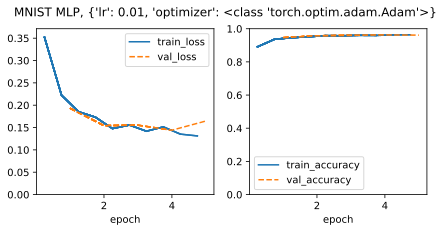

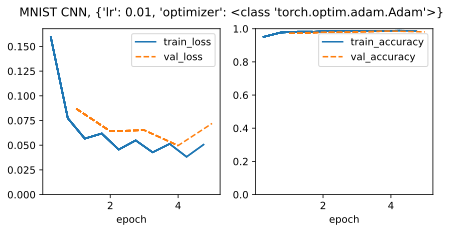

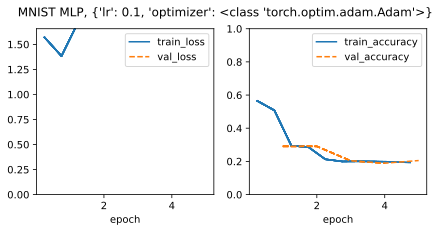

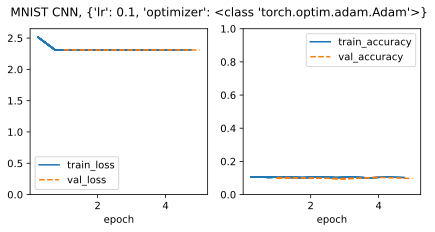

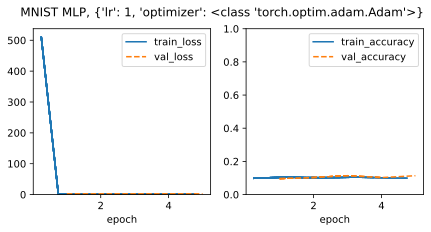

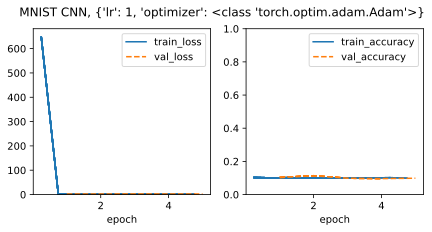

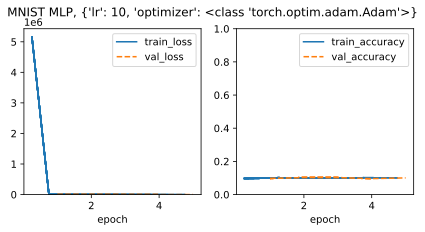

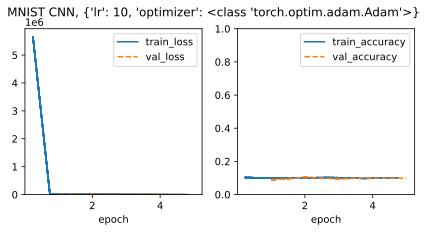

In [7]:
for i, optimizer in enumerate(optimizer_sweep):
    for lr in lr_sweep:
        mlp_hp = get_hp('MLP', 'MNIST', lr=lr, optimizer=optimizer)
        cnn_hp = get_hp('CNN', 'MNIST', lr=lr, optimizer=optimizer)
        mlp_model = fit(mlp_hp, device=device)
        cnn_model = fit(cnn_hp, device=device)
        _, mlp_val_accuracy = val_stats(mlp_model, mlp_hp, device=device)
        _, cnn_val_accuracy = val_stats(cnn_model, cnn_hp, device=device)
        mlp_val_accuracies[i][0].append(mlp_val_accuracy)
        cnn_val_accuracies[i][0].append(cnn_val_accuracy)
plt.show()

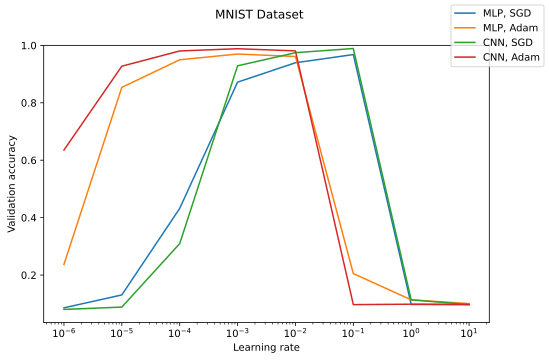

In [13]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(lr_sweep, mlp_val_accuracies[0][0], label="MLP, SGD")
axs.plot(lr_sweep, mlp_val_accuracies[1][0], label="MLP, Adam")
axs.plot(lr_sweep, cnn_val_accuracies[0][0], label="CNN, SGD")
axs.plot(lr_sweep, cnn_val_accuracies[1][0], label="CNN, Adam")
axs.set_xscale('log')
axs.set_xlabel("Learning rate")
axs.set_ylabel("Validation accuracy")
axs.set_ylim([None,1])
fig.suptitle('MNIST Dataset')
fig.legend();

### Fashion-MNIST Experiments

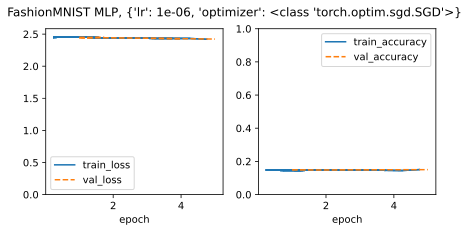

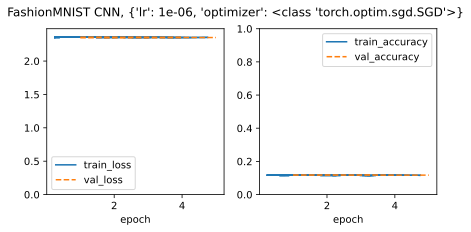

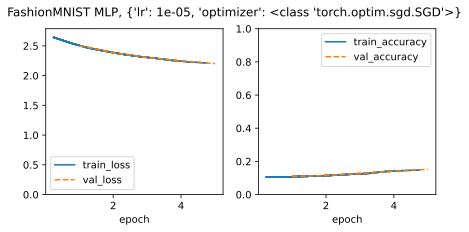

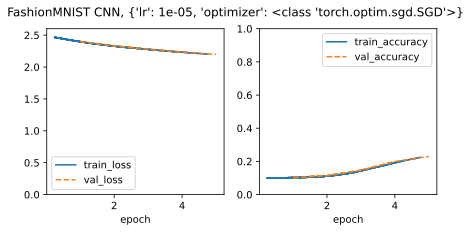

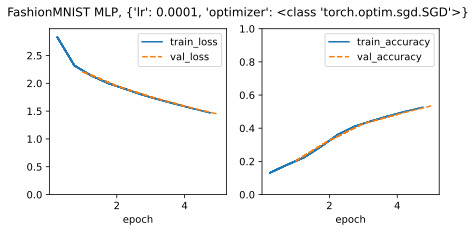

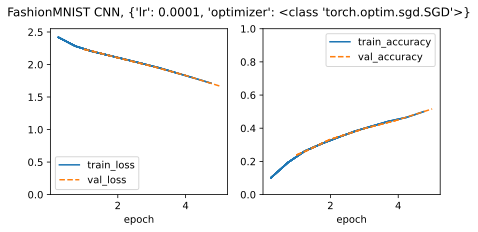

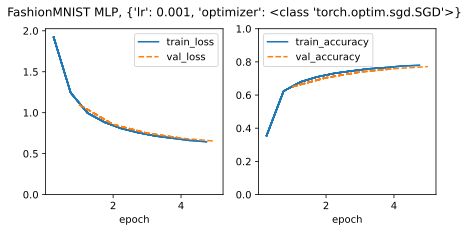

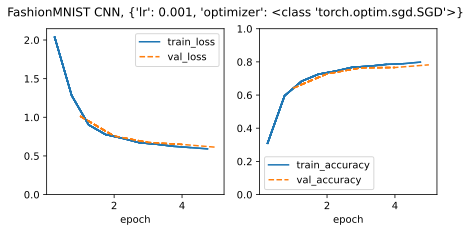

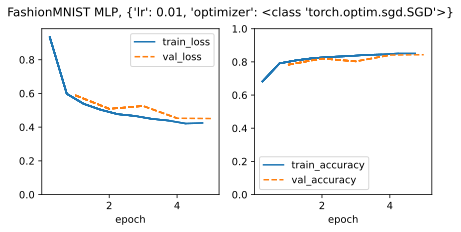

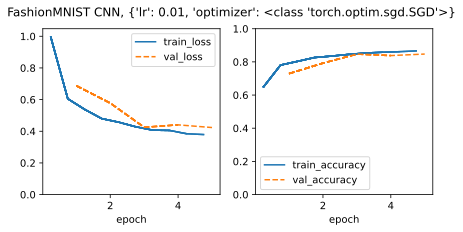

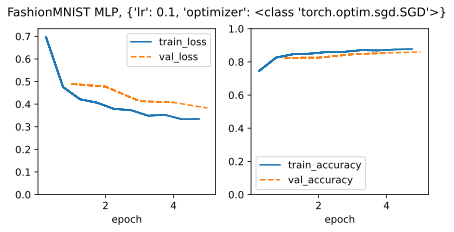

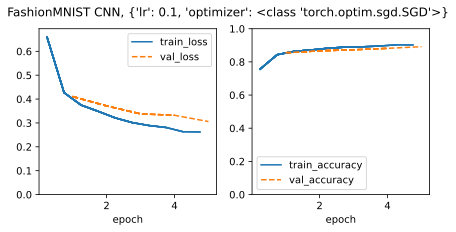

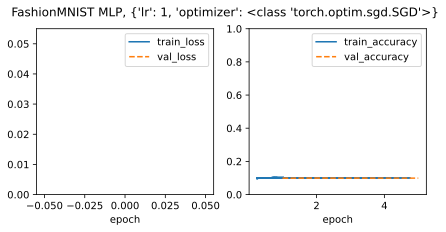

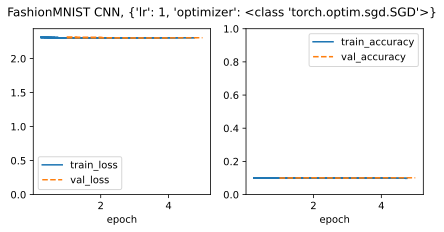

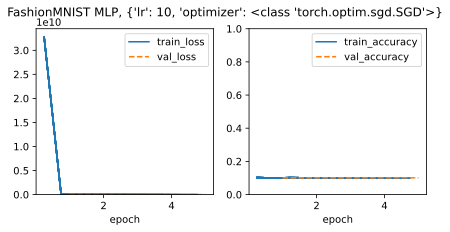

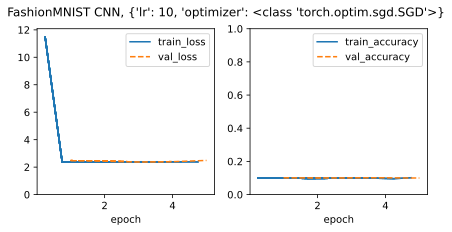

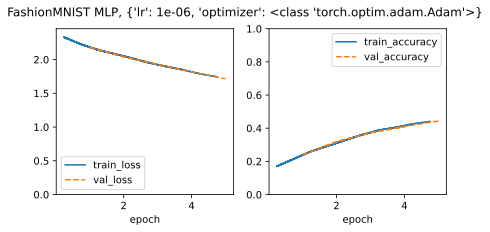

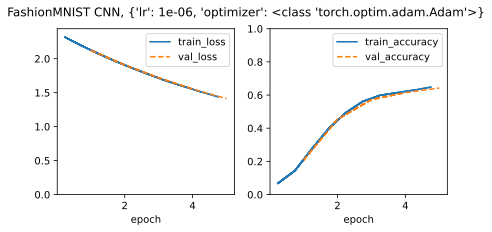

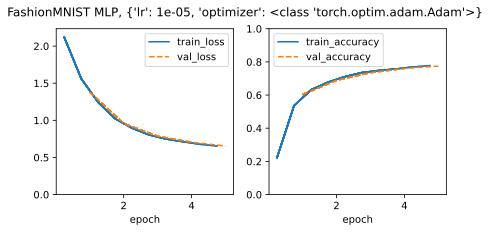

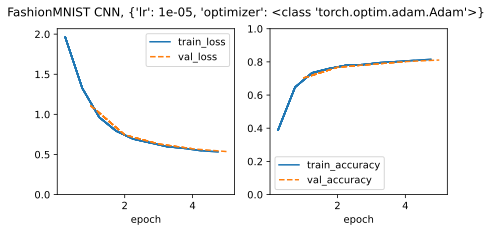

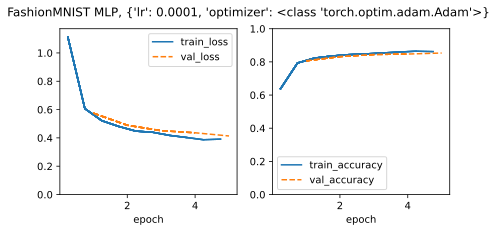

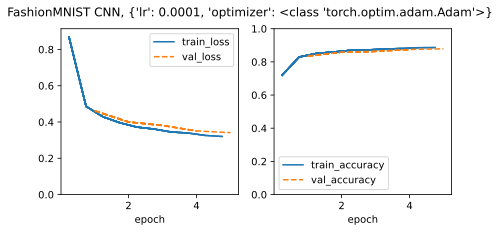

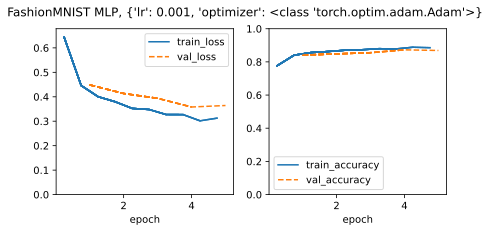

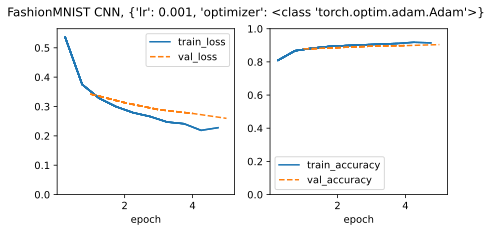

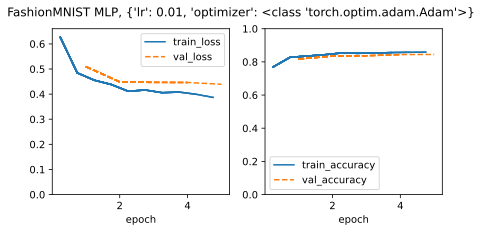

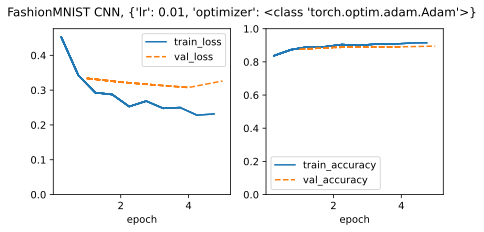

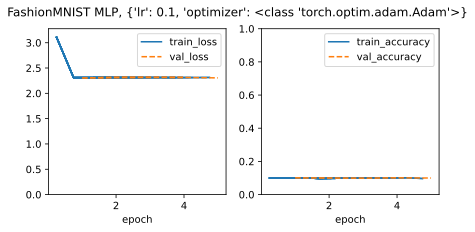

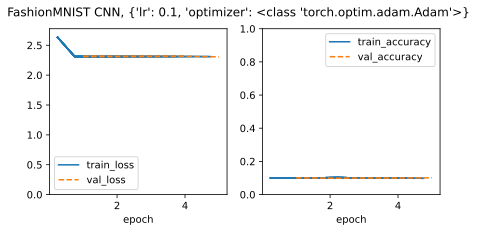

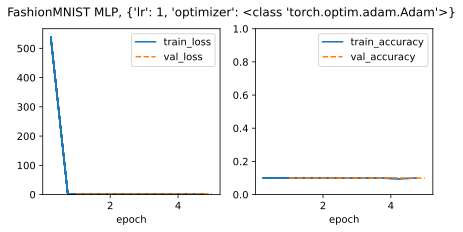

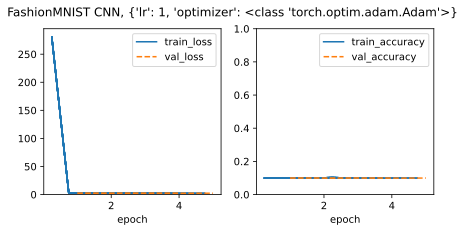

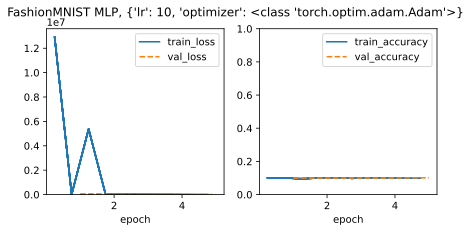

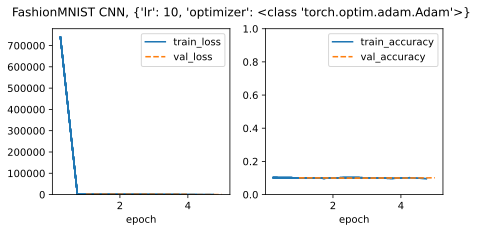

In [9]:
for i, optimizer in enumerate(optimizer_sweep):
    for lr in lr_sweep:
        mlp_hp = get_hp('MLP', 'FashionMNIST', lr=lr, optimizer=optimizer)
        cnn_hp = get_hp('CNN', 'FashionMNIST', lr=lr, optimizer=optimizer)
        mlp_model = fit(mlp_hp, device=device)
        cnn_model = fit(cnn_hp, device=device)
        _, mlp_val_accuracy = val_stats(mlp_model, mlp_hp, device=device)
        _, cnn_val_accuracy = val_stats(cnn_model, cnn_hp, device=device)
        mlp_val_accuracies[i][1].append(mlp_val_accuracy)
        cnn_val_accuracies[i][1].append(cnn_val_accuracy)
plt.show()

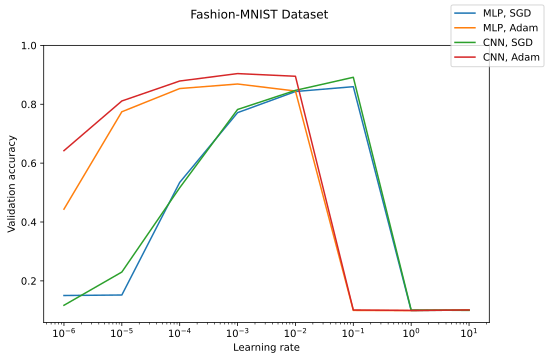

In [10]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(lr_sweep, mlp_val_accuracies[0][1], label="MLP, SGD")
axs.plot(lr_sweep, mlp_val_accuracies[1][1], label="MLP, Adam")
axs.plot(lr_sweep, cnn_val_accuracies[0][1], label="CNN, SGD")
axs.plot(lr_sweep, cnn_val_accuracies[1][1], label="CNN, Adam")
axs.set_xscale('log')
axs.set_xlabel("Learning rate")
axs.set_ylabel("Validation accuracy")
axs.set_ylim([None,1])
fig.suptitle('Fashion-MNIST Dataset')
fig.legend();

### CIFAR-10 Experiments

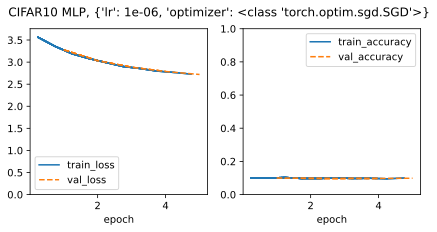

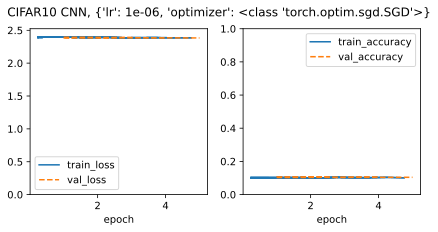

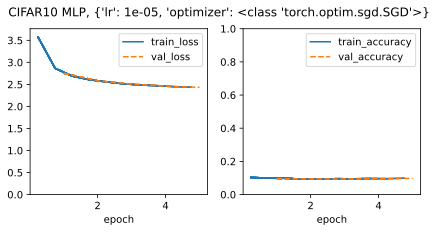

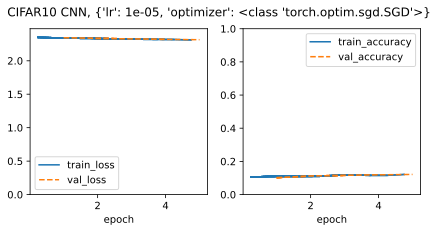

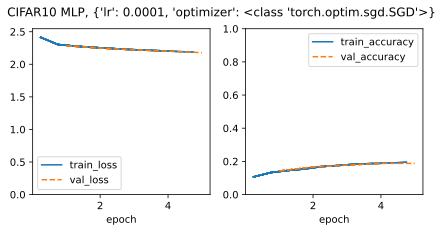

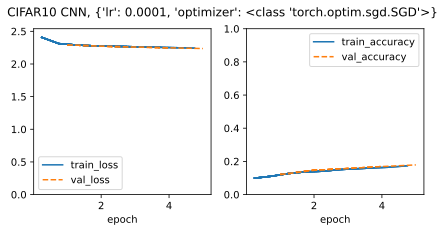

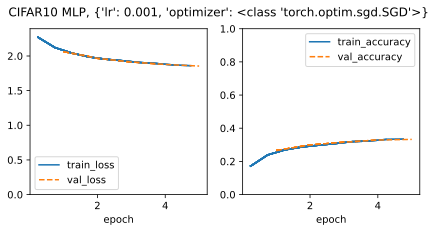

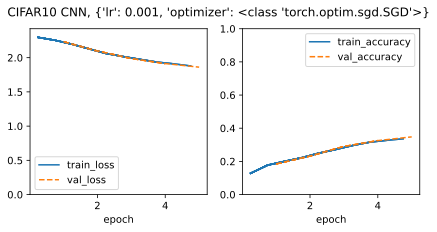

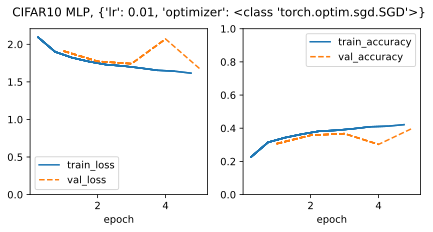

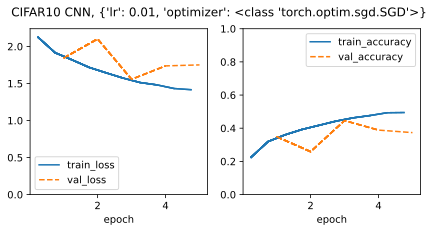

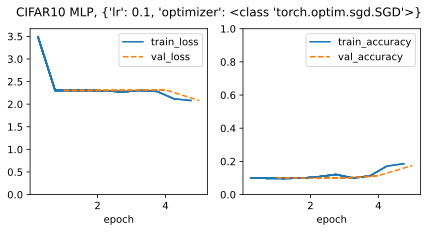

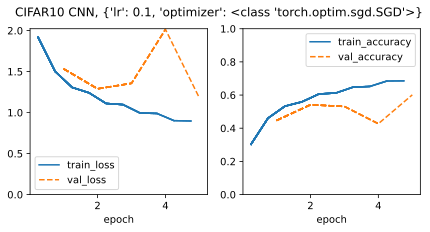

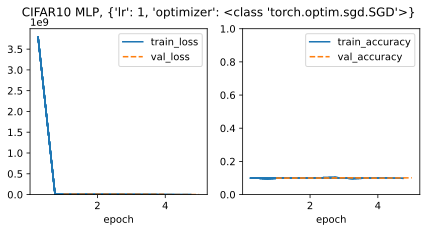

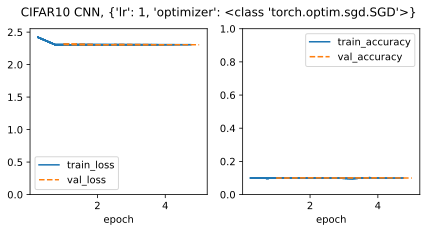

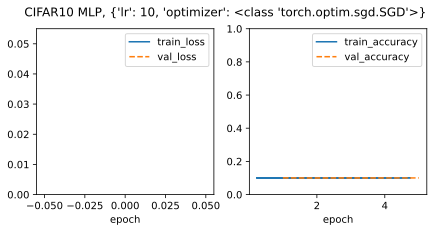

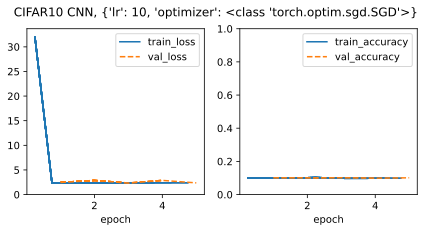

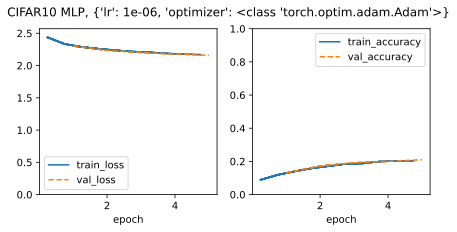

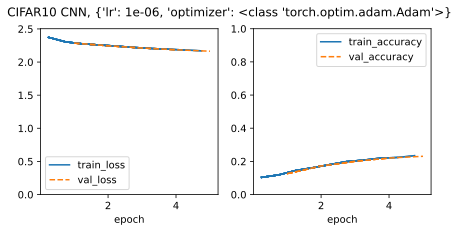

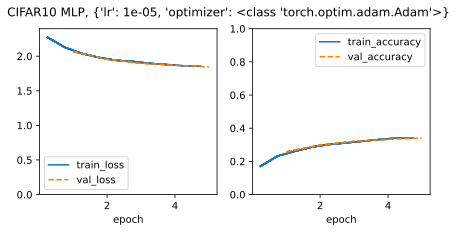

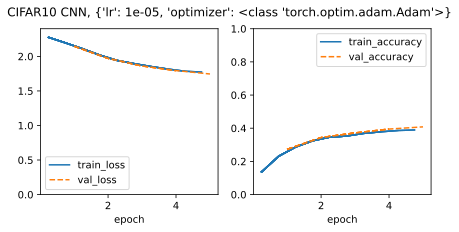

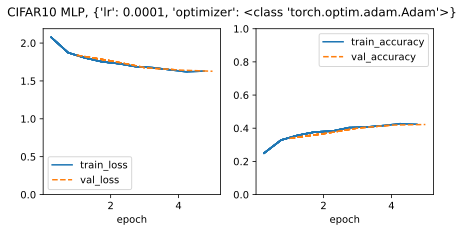

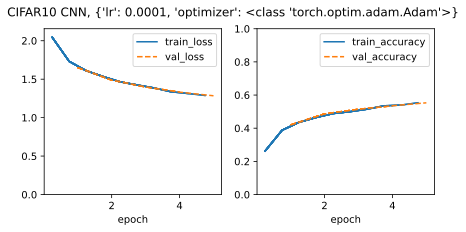

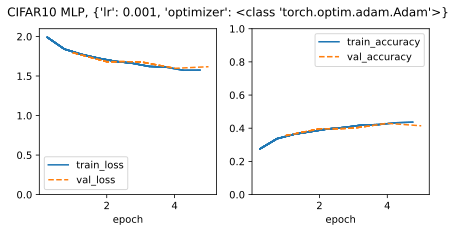

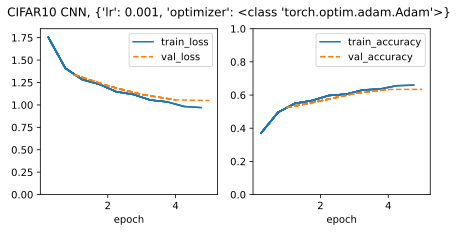

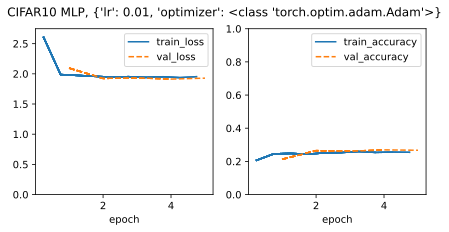

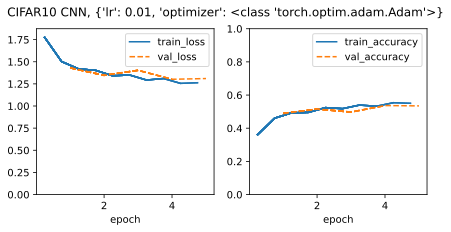

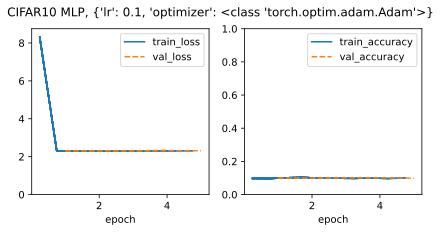

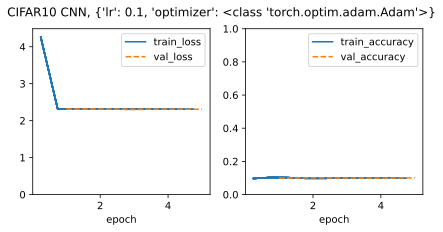

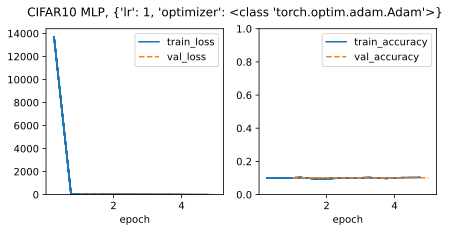

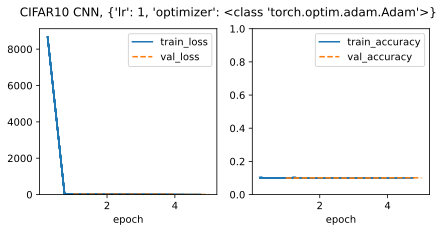

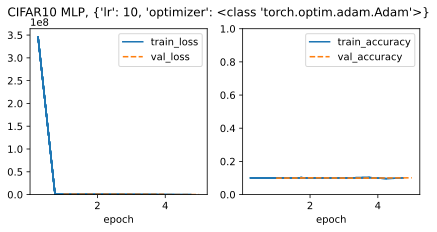

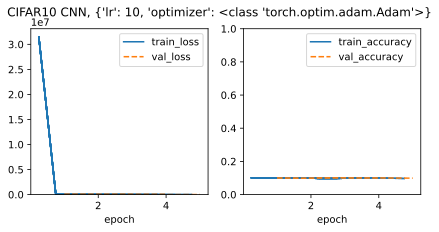

In [11]:
for i, optimizer in enumerate(optimizer_sweep):
    for lr in lr_sweep:
        mlp_hp = get_hp('MLP', 'CIFAR10', lr=lr, optimizer=optimizer)
        cnn_hp = get_hp('CNN', 'CIFAR10', lr=lr, optimizer=optimizer)
        mlp_model = fit(mlp_hp, device=device)
        cnn_model = fit(cnn_hp, device=device)
        _, mlp_val_accuracy = val_stats(mlp_model, mlp_hp, device=device)
        _, cnn_val_accuracy = val_stats(cnn_model, cnn_hp, device=device)
        mlp_val_accuracies[i][2].append(mlp_val_accuracy)
        cnn_val_accuracies[i][2].append(cnn_val_accuracy)
plt.show()

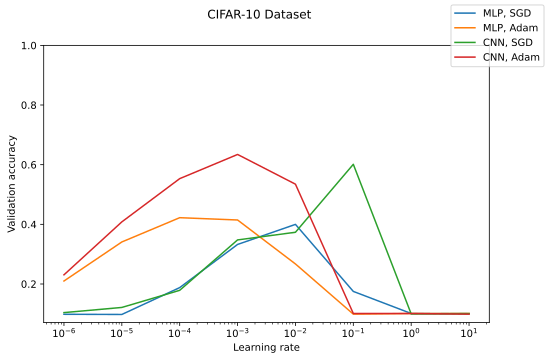

In [12]:
fig, axs = plt.subplots(figsize=(8, 5))
axs.plot(lr_sweep, mlp_val_accuracies[0][2], label="MLP, SGD")
axs.plot(lr_sweep, mlp_val_accuracies[1][2], label="MLP, Adam")
axs.plot(lr_sweep, cnn_val_accuracies[0][2], label="CNN, SGD")
axs.plot(lr_sweep, cnn_val_accuracies[1][2], label="CNN, Adam")
axs.set_xscale('log')
axs.set_xlabel("Learning rate")
axs.set_ylabel("Validation accuracy")
axs.set_ylim([None,1])
fig.suptitle('CIFAR-10 Dataset')
fig.legend();